In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')

# # Set visualization style
# sns.set_style('whitegrid')
# plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\aakri\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
#ss= pd.read_csv('SampleSubmission.csv')
variable_definitions = pd.read_csv('VariableDefinitions.csv')

In [3]:
pd.set_option('display.max_colwidth', None)

## 🔍 Dataset Overview

In [9]:
# ========================================
# 1. DATASET OVERVIEW
# ========================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTrain Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape: {test_df.shape}")
print(f"\nNumber of Features in Train: {train_df.shape[1]}")
print(f"Number of Features in Test: {test_df.shape[1]}")

DATASET OVERVIEW

Train Dataset Shape: (9618, 39)
Test Dataset Shape: (2405, 38)

Number of Features in Train: 39
Number of Features in Test: 38


In [10]:
display(variable_definitions)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatini/Lesotho/Malawi/Zimbabwe)
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable business environment in the future
4,attitude_worried_shutdown,Owner attitude: Worried that the business will shut down
5,compliance_income_tax,Business complies with or acts in accordance with income tax regulations
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the kinds of losses the business suffers
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance payments
8,personal_income,Total monthly personal income of the owner before tax and other deductions
9,business_expenses,Approximate monthly or annual expenses of the business in local currency


In [11]:
display(train_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [12]:
display(test_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


## 🎯 Target Variable Analysis (FHI)

This section explores the **target variable (`FHI`)** to understand its distribution and check for potential class imbalance, which is critical for selecting appropriate modeling and evaluation strategies.

### 📊 Distribution Overview
- Displays the **count** of each `FHI` class  
- Shows the **proportion (%)** of each class relative to the full dataset  

This helps identify whether some classes are under-represented.

### 📈 Visualizations
Two complementary plots are generated:

1. **Bar Chart**
   - Shows the absolute frequency of each `FHI` class  
   - Useful for quickly spotting dominance or rarity of classes  

2. **Pie Chart**
   - Displays class proportions as percentages  
   - Offers an intuitive view of class balance  

### ⚖️ Class Imbalance Check
- Computes the ratio between the **largest** and **smallest** class  
- A warning is raised if the ratio exceeds **1.5 : 1**, indicating possible imbalance  
- Balanced classes suggest standard modeling approaches are appropriate  
- Imbalanced classes may require:
  - Class weighting  
  - Resampling techniques  
  - Specialized evaluation metrics  

### ✅ Why this matters
Understanding the nature of the target variable ensures:
- Fair model training  
- Reliable evaluation  
- Better generalization to unseen data  

This step lays a strong foundation before feature engineering and model development.

---



TARGET VARIABLE ANALYSIS

Target Distribution:
High       470
Low       6280
Medium    2868
Name: Target, dtype: int64

Target Proportions:
High      0.048867
Low       0.652942
Medium    0.298191
Name: Target, dtype: float64


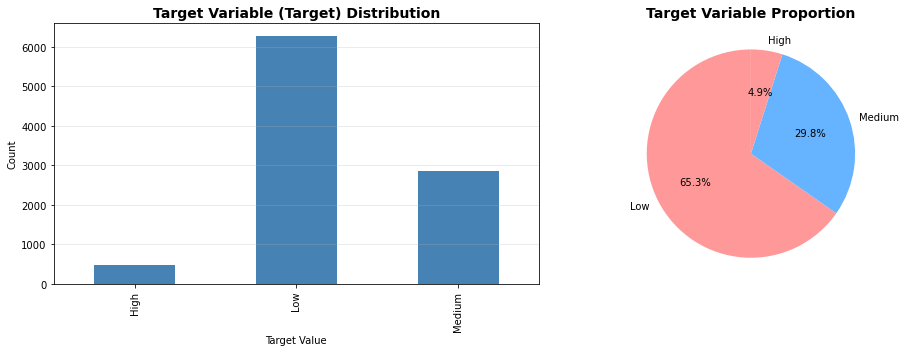


⚠ Class imbalance detected! Ratio: 13.36:1


In [15]:
# ========================================
# 2. TARGET VARIABLE ANALYSIS (Target)
# ========================================

print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

if 'Target' in train_df.columns:
    print("\nTarget Distribution:")
    print(train_df['Target'].value_counts().sort_index())
    print(f"\nTarget Proportions:")
    print(train_df['Target'].value_counts(normalize=True).sort_index())
    
    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    train_df['Target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Target Variable (Target) Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Target Value')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart
    target_counts = train_df['Target'].value_counts()
    axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
                startangle=90, colors=['#ff9999', '#66b3ff'])
    axes[1].set_title('Target Variable Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Check for class imbalance
    class_ratio = train_df['Target'].value_counts().max() / train_df['Target'].value_counts().min()
    if class_ratio > 1.5:
        print(f"\n⚠ Class imbalance detected! Ratio: {class_ratio:.2f}:1")
    else:
        print(f"\n✓ Classes are relatively balanced. Ratio: {class_ratio:.2f}:1")

## 🧾 Basic Dataset Information

This section provides a structural overview of the **training** and **test** datasets using `DataFrame.info()`.

### 🔎 What is examined?
For both datasets, the following details are displayed:

- **Number of rows and columns**
- **Column names**
- **Data types** of each feature
- **Non-null counts**, helping to identify missing values
- **Memory usage**

### 📘 Train vs Test
- The **training set** includes all input features **plus the target variable (`FHI`)**
- The **test set** contains only input features, ensuring no data leakage

### ✅ Why this matters
- Confirms that data types are correctly inferred  
- Helps detect columns that may require:
  - Type casting  
  - Missing value handling  
  - Feature engineering  

This is an essential diagnostic step before performing data cleaning, exploratory analysis, and model training.

---

In [17]:
# ========================================
# 3. BASIC INFORMATION
# ========================================

print("\n" + "=" * 60)
print("BASIC DATASET INFORMATION")
print("=" * 60)

print("\n--- TRAIN SET INFO ---")
print(train_df.info())

print("\n--- TEST SET INFO ---")
print(test_df.info())


BASIC DATASET INFORMATION

--- TRAIN SET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-nu

## 🧩 Missing Values Analysis

This section analyzes **missing data patterns** in both the training and test datasets, helping identify features that may require imputation, transformation, or removal.

### 🔍 What the analysis does
For each dataset (**train** and **test**):

- Calculates the **number of missing values** per column  
- Computes the **percentage of missing values** relative to the dataset size  
- Filters and displays only columns that contain missing data  
- Sorts columns by missing percentage (highest to lowest)

### 📋 Tabular Summary
A table is printed showing:
- **Column name**
- **Missing value count**
- **Percentage of missing values**

This makes it easy to spot problematic features at a glance.

### 📊 Visualization
- A **horizontal bar chart** displays the top 15 columns with the highest proportion of missing values  
- Percentages are plotted for clearer interpretation  
- The inverse y-axis ensures the most affected columns appear at the top

### ✅ Why this matters
Understanding missingness helps guide:
- Feature selection and removal  
- Choice of imputation strategy (mean, median, mode, model-based, etc.)  
- Detection of systematic data collection issues  

This step confirms data quality before moving on to feature engineering and model training.

---



MISSING VALUES ANALYSIS

TRAIN SET - Columns with Missing Values:
                                                          Column  Missing_Count  Percentage
                                            uses_informal_lender           4489   46.672905
                                     uses_friends_family_savings           4488   46.662508
                                      motivation_make_more_money           4291   44.614265
                                               funeral_insurance           4188   43.543356
                                               medical_insurance           4188   43.543356
                                             business_age_months           4111   42.742774
                                         future_risk_theft_stock           4100   42.628405
                                                  has_debit_card           4003   41.619879
                                            has_internet_banking           4003   41.619879
             

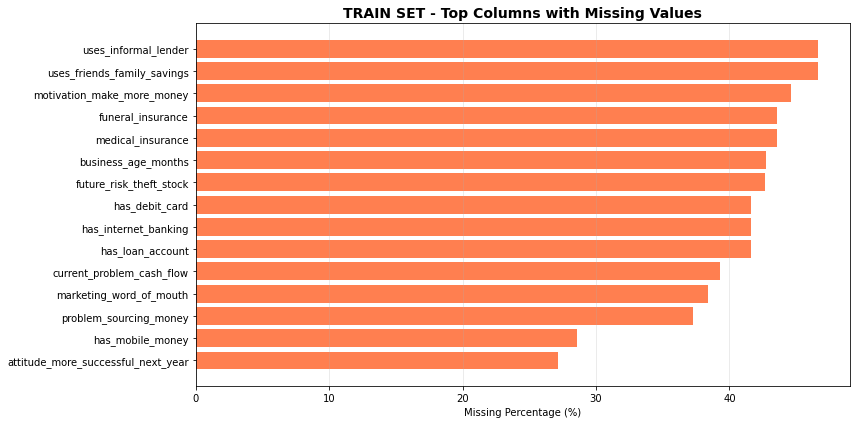


TEST SET - Columns with Missing Values:
                                                          Column  Missing_Count  Percentage
                                            uses_informal_lender           1131   47.027027
                                     uses_friends_family_savings           1131   47.027027
                                      motivation_make_more_money           1084   45.072765
                                               funeral_insurance           1042   43.326403
                                               medical_insurance           1042   43.326403
                                             business_age_months           1033   42.952183
                                         future_risk_theft_stock           1017   42.286902
                                                has_loan_account            992   41.247401
                                            has_internet_banking            992   41.247401
                                       

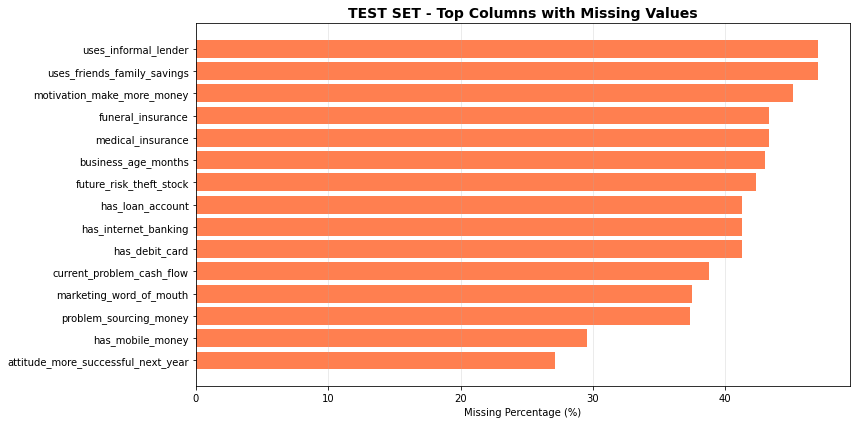

In [18]:
# ========================================
# 4. MISSING VALUES ANALYSIS
# ========================================

print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

def analyze_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Percentage': missing_pct.values
    }).query('Missing_Count > 0').sort_values('Percentage', ascending=False)
    
    print(f"\n{name} - Columns with Missing Values:")
    if len(missing_df) > 0:
        print(missing_df.to_string(index=False))
        
        # Visualize top missing columns
        if len(missing_df) > 0:
            top_missing = missing_df.head(15)
            plt.figure(figsize=(12, 6))
            plt.barh(top_missing['Column'], top_missing['Percentage'], color='coral')
            plt.xlabel('Missing Percentage (%)')
            plt.title(f'{name} - Top Columns with Missing Values', fontsize=14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("No missing values found!")
    
    return missing_df

train_missing = analyze_missing(train_df, "TRAIN SET")
test_missing = analyze_missing(test_df, "TEST SET")

## 🔢 Numerical Features Analysis

This section examines the **numerical variables** in the training dataset to understand their distributions, scales, and summary statistics.

### 🧮 Identifying Numerical Features
- Automatically selects features with `int64` and `float64` data types  
- Excludes the target variable (`FHI`) to avoid data leakage  
- Reports the total number of numerical features and lists their names  

### 📊 Statistical Summary
- Generates descriptive statistics using `.describe()`:
  - Count
  - Mean
  - Standard deviation
  - Minimum and maximum values
  - Quartiles (25%, 50%, 75%)

This provides insight into:
- Value ranges and spread  
- Potential outliers  
- Skewness and scaling differences  

### 📈 Distribution Visualizations
- Plots histograms for selected **key numerical features** (if present), such as:
  - Owner age  
  - Personal income  
  - Business expenses  
  - Business age (in months)  
- Uses consistent binning and gridlines for clarity  

These plots help identify:
- Skewed distributions  
- Extreme values  
- Features that may benefit from transformations (e.g., log-scaling)

### ✅ Why this matters
Understanding numerical distributions is critical for:
- Feature scaling and normalization  
- Outlier treatment  
- Choosing appropriate modeling techniques  

This analysis sets the stage for smarter feature engineering and model optimization.

---



NUMERICAL FEATURES ANALYSIS

Numerical Features (6):
['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']

Statistical Summary:
         owner_age  personal_income  business_expenses  business_turnover  \
count  9618.000000     9.509000e+03       9.389000e+03       9.402000e+03   
mean     41.705344     2.627345e+05       4.583838e+05       1.348210e+06   
std      13.314010     2.566268e+06       6.184746e+06       8.804741e+06   
min      18.000000     0.000000e+00       0.000000e+00       0.000000e+00   
25%      32.000000     3.000000e+02       7.000000e+02       1.500000e+03   
50%      40.000000     2.000000e+03       3.000000e+03       6.000000e+03   
75%      50.000000     2.500000e+04       2.500000e+04       5.000000e+04   
max     103.000000     1.500000e+08       5.000000e+08       4.200000e+08   

       business_age_years  business_age_months  
count         9366.000000          5507.000000  
mean        

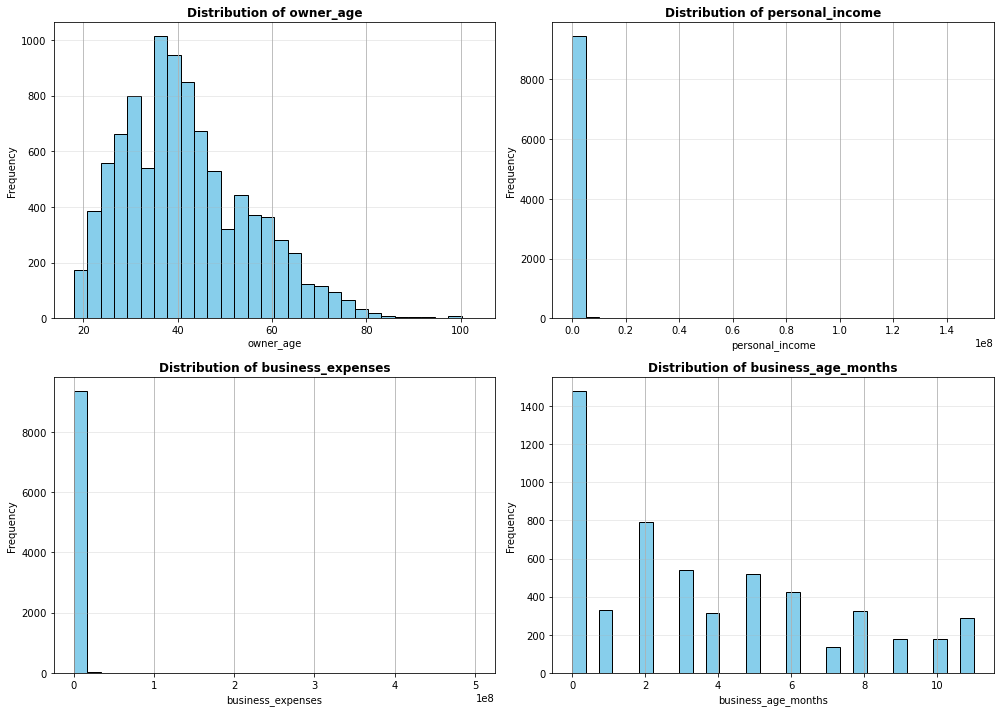

In [27]:
# ========================================
# 5. NUMERICAL FEATURES ANALYSIS
# ========================================

print("\n" + "=" * 60)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 60)

# Identify numerical columns
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

print(f"\nNumerical Features ({len(numerical_cols)}):")
print(numerical_cols)

# Statistical summary
print("\nStatistical Summary:")
print(train_df[numerical_cols].describe())

# Visualize distributions of few numerical features
key_numerical = ['owner_age', 'personal_income', 'business_expenses', 'business_age_months']
available_numerical = [col for col in key_numerical if col in train_df.columns]

if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(available_numerical[:4]):
        train_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 🏷️ Categorical Features Analysis

This section explores the **categorical variables** in the training dataset, focusing on their quantity, variety, and uniqueness.

### 🧭 Identifying Categorical Features
- Selects all features with `object` data types  
- Excludes the `ID` column, as it serves only as an identifier and carries no predictive value  
- Displays the total number of categorical features and their names  

### 🔢 Cardinality Analysis
For each categorical feature, the analysis computes:
- **Number of unique values (cardinality)**  

The results are presented in a sorted table, from highest to lowest cardinality.

### ✅ Why this matters
Understanding categorical cardinality helps guide:
- Encoding strategy selection:
  - Low cardinality → One-hot encoding  
  - High cardinality → Target encoding, frequency encoding, or embedding-based approaches  
- Identification of features that may:
  - Cause overfitting  
  - Increase model complexity unnecessarily  

This step ensures categorical features are handled efficiently and appropriately during feature engineering and model training.

---


In [28]:
# ========================================
# 6. CATEGORICAL FEATURES ANALYSIS
# ========================================

print("\n" + "=" * 60)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'ID' in categorical_cols:
    categorical_cols.remove('ID')

print(f"\nCategorical Features ({len(categorical_cols)}):")
print(categorical_cols)

# Cardinality analysis
print("\nCardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique_Values': [train_df[col].nunique() for col in categorical_cols]
}).sort_values('Unique_Values', ascending=False)
print(cardinality_df.to_string(index=False))


CATEGORICAL FEATURES ANALYSIS

Categorical Features (32):
['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender', 'Target']

Cardinality (Unique Values) for Categorical Features:
              

## 🌍 Country Distribution

This section analyzes how observations are distributed across **countries** in both the training and test datasets.

### 📊 Frequency Analysis
- Displays the **count of records per country** in:
  - The training dataset  
  - The test dataset  
- Helps verify whether both datasets reflect similar geographic coverage.

### 📈 Visualization
Two bar charts are generated side by side:
- **Train Set Country Distribution**
- **Test Set Country Distribution**

The charts:
- Show sample size differences across countries  
- Highlight potential regional imbalance  
- Rotate x-axis labels for improved readability  

### ✅ Why this matters
Understanding country-level distribution is important because:
- Models may learn **country-specific patterns**  
- Large imbalances can bias predictions toward dominant countries  
- It informs whether:
  - Country should be used as a feature  
  - Country-specific models or stratified validation may be beneficial  

This step ensures geographic representation is well understood before proceeding to modeling.

---



COUNTRY DISTRIBUTION

Train Set Country Distribution:
eswatini    2674
zimbabwe    2612
malawi      2388
lesotho     1944
Name: country, dtype: int64

Test Set Country Distribution:
eswatini    669
zimbabwe    653
malawi      597
lesotho     486
Name: country, dtype: int64


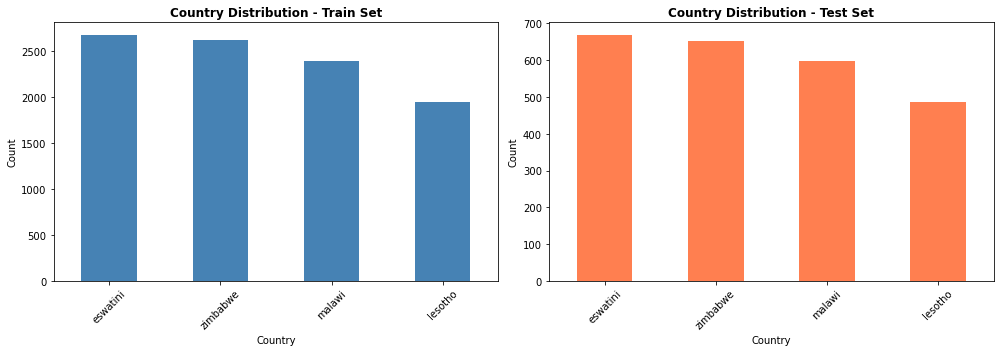

In [29]:
# ========================================
# 7. COUNTRY DISTRIBUTION
# ========================================

print("\n" + "=" * 60)
print("COUNTRY DISTRIBUTION")
print("=" * 60)

if 'country' in train_df.columns:
    print("\nTrain Set Country Distribution:")
    print(train_df['country'].value_counts())
    
    print("\nTest Set Country Distribution:")
    print(test_df['country'].value_counts())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    train_df['country'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Country Distribution - Train Set', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Country')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    test_df['country'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Country Distribution - Test Set', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Country')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 🧪 Data Quality Checks

This section performs key **data integrity checks** to ensure the dataset is reliable and ready for modeling.

### 🔹 Duplicate ID Check
- Counts **duplicate IDs** in both train and test sets  
- Duplicate identifiers may indicate repeated records, which can bias model training

### 🔹 Train-Test ID Overlap
- Identifies IDs present in **both train and test sets**  
- Overlapping IDs could lead to **data leakage** and inflated model performance

### 🔹 Feature Consistency Check
- Compares columns in train and test datasets (excluding the target `FHI`)  
- Detects:
  - Features present in train but missing in test  
  - Features present in test but missing in train  
- Ensures that both datasets are aligned for modeling  

### ✅ Why this matters
- Confirms the datasets are clean, consistent, and free from critical integrity issues  
- Prevents:
  - Modeling errors due to missing features  
  - Leakage from overlapping IDs  
  - Unexpected mismatches during prediction or submission  

Performing these checks is a crucial final step before **feature engineering and model development**.

---


In [30]:
# ========================================
# 8. DATA QUALITY CHECKS
# ========================================

print("\n" + "=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# Check for duplicate IDs
print(f"\nDuplicate IDs in Train: {train_df['ID'].duplicated().sum()}")
print(f"Duplicate IDs in Test: {test_df['ID'].duplicated().sum()}")

# Check for ID overlap
id_overlap = set(train_df['ID']).intersection(set(test_df['ID']))
print(f"Overlapping IDs between Train and Test: {len(id_overlap)}")

# Check feature consistency
train_cols = set(train_df.columns) - {'FHI'}
test_cols = set(test_df.columns)
missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols

if missing_in_test:
    print(f"\n⚠ Features in Train but not in Test: {missing_in_test}")
if extra_in_test:
    print(f"\n⚠ Features in Test but not in Train: {extra_in_test}")
if not missing_in_test and not extra_in_test:
    print("\n✓ Feature sets are consistent (except target variable)")


DATA QUALITY CHECKS

Duplicate IDs in Train: 0
Duplicate IDs in Test: 0
Overlapping IDs between Train and Test: 0

⚠ Features in Train but not in Test: {'Target'}


## 📝 Key Insights & Recommendations

This final section summarizes the main findings from the exploratory data analysis (EDA) and outlines actionable next steps for modeling.

### 📊 EDA Summary
- **Total training samples:** `len(train_df)`  
- **Total test samples:** `len(test_df)`  
- **Number of features:** `len(categorical_cols) + len(numerical_cols)`  
- **Numerical features:** `len(numerical_cols)`  
- **Categorical features:** `len(categorical_cols)`  

### ⚠ Missing Data
- **Features with missing values:** `len(train_missing)`  
- **Maximum missing percentage:** `train_missing['Percentage'].max():.1f%`  


In [32]:
# ========================================
# 9. KEY INSIGHTS SUMMARY
# ========================================

print("\n" + "=" * 60)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("\n📊 EDA SUMMARY:")
print(f"• Total training samples: {len(train_df):,}")
print(f"• Total test samples: {len(test_df):,}")
print(f"• Number of features: {len(categorical_cols) + len(numerical_cols)}")
print(f"• Numerical features: {len(numerical_cols)}")
print(f"• Categorical features: {len(categorical_cols)}")

if len(train_missing) > 0:
    print(f"\n⚠ Missing Data:")
    print(f"• Features with missing values: {len(train_missing)}")
    print(f"• Highest missing percentage: {train_missing['Percentage'].max():.1f}%")

print("\n" + "=" * 60)
print("EDA COMPLETE!")
print("=" * 60)


KEY INSIGHTS & RECOMMENDATIONS

📊 EDA SUMMARY:
• Total training samples: 9,618
• Total test samples: 2,405
• Number of features: 38
• Numerical features: 6
• Categorical features: 32

⚠ Missing Data:
• Features with missing values: 35
• Highest missing percentage: 46.7%

EDA COMPLETE!


## Ordinal Encoding

In [3]:
pd.unique(train_df[["motor_vehicle_insurance","medical_insurance","funeral_insurance"]].values.ravel("C"))

array(['Never had', 'Used to have but don’t have now', 'Have now', nan,
       "Used to have but don't have now", "Don't know",
       'Don’t know (Do not show)'], dtype=object)

In [4]:
pd.unique(test_df[["motor_vehicle_insurance","medical_insurance","funeral_insurance"]].values.ravel("C"))

array(['Never had', nan, 'Have now', 'Used to have but don’t have now',
       "Used to have but don't have now", "Don't know",
       'Don’t know (Do not show)'], dtype=object)

In [4]:
# Define a mapping that captures EVERY possible state
ordinal_map = {
    'Have now': 3,
    "Used to have but don’t have now": 2,
    "Used to have but don't have now": 2,
    "Don't know": 1,
    "Don’t know (Do not show)":1,
    'Never had': 0
}

# Apply to columns
for col in ['funeral_insurance', 'medical_insurance', 'motor_vehicle_insurance']:
    # 1. Standardize the "Missing" strings first
    train_df[col] = train_df[col].fillna('Never had')
    test_df[col] = test_df[col].fillna('Never had') 
    
# Map the strings to numbers
    train_df[col] = train_df[col].map(ordinal_map)
    test_df[col] = test_df[col].map(ordinal_map)
    
# Handle anything that didn't match the map (safety net)
    train_df[col] = train_df[col].fillna(0).astype(int)
    test_df[col] = test_df[col].fillna(0).astype(int)

In [5]:
pd.unique(train_df[["motor_vehicle_insurance","medical_insurance","funeral_insurance"]].values.ravel("C"))

array([0, 2, 3, 1])

In [6]:
pd.unique(test_df[["motor_vehicle_insurance","medical_insurance","funeral_insurance"]].values.ravel("C"))

array([0, 3, 2, 1])

## Missing Value handling- Categorical Variables

In [7]:
# List 32 categorical columns
cat_cols = ['attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax',
            'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance',
            'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 
            'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 
            'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important',
            'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money',
            'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card',
            'future_risk_theft_stock', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender'] 

# Initialize the imputer. This replaces every null with the string 'Missing'
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')

# Apply it to dataframe
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])
test_df[cat_cols] = cat_imputer.fit_transform(test_df[cat_cols])

In [8]:
# ========================================
# Running missing value cell again
# ========================================
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

def analyze_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Percentage': missing_pct.values
    }).query('Missing_Count > 0').sort_values('Percentage', ascending=False)
    
    print(f"\n{name} - Columns with Missing Values:")
    if len(missing_df) > 0:
        print(missing_df.to_string(index=False))
    else:
        print("No missing values found!")
    
    return missing_df

train_missing = analyze_missing(train_df, "TRAIN SET")
test_missing = analyze_missing(test_df, "TEST SET")


MISSING VALUES ANALYSIS

TRAIN SET - Columns with Missing Values:
             Column  Missing_Count  Percentage
business_age_months           4111   42.742774
 business_age_years            252    2.620087
  business_expenses            229    2.380952
  business_turnover            216    2.245789
    personal_income            109    1.133292

TEST SET - Columns with Missing Values:
             Column  Missing_Count  Percentage
business_age_months           1033   42.952183
  business_expenses             70    2.910603
  business_turnover             70    2.910603
 business_age_years             59    2.453222
    personal_income             23    0.956341
          owner_age              1    0.041580


## Standardize Text- Categorical Variables

In [9]:
def standardize_text(df):
    for col in cat_cols:
        # Standardize quotes and lowercase
        df[col] = df[col].astype(str).str.replace('’', "'").str.lower().str.strip()
    return df

train_df = standardize_text(train_df)
test_df = standardize_text(test_df)

In [10]:
# List all the columns that have those "empty" values
cols_to_clean = ['attitude_worried_shutdown', 'attitude_stable_business_environment', 'compliance_income_tax', 
                 'perception_insurance_doesnt_cover_losses','perception_cannot_afford_insurance',
                'has_mobile_money','current_problem_cash_flow','attitude_satisfied_with_achievement','has_credit_card']

# Loop through and replace the values in one go
for col in cols_to_clean:
    train_df[col] = train_df[col].replace(["don't know or n/a","don't know","0"], 'missing')
    test_df[col] = test_df[col].replace(["don't know or n/a","don't know","0"], 'missing')

In [11]:
# Replace the hardcoded string with actual NaN
train_df.replace("missing", np.nan, inplace=True)
test_df.replace("missing", np.nan, inplace=True)

In [12]:
imputer = SimpleImputer(strategy='most_frequent')

# 3. Fill the missing values
train_df[cat_cols] = imputer.fit_transform(train_df[cat_cols])
test_df[cat_cols] = imputer.fit_transform(test_df[cat_cols])

## Missing Value Handling-Numerical

In [13]:
# 1. Define 5 numerical columns 
num_cols_to_fix = [
    'personal_income', 
    'business_expenses', 
    'business_turnover',
    'business_age_years',
    'owner_age'# empty value in test
]


all_num_features = num_cols_to_fix 

# 2. Initialize the Median Imputer
# Strategy='median' is robust against outliers in financial data
imputer = SimpleImputer(strategy='median')

# 3. Fill the missing values
train_df[num_cols_to_fix] = imputer.fit_transform(train_df[num_cols_to_fix])
test_df[num_cols_to_fix] = imputer.fit_transform(test_df[num_cols_to_fix])

# 4. Scale the features (Essential for most classifiers)
scaler = StandardScaler()
train_df[num_cols_to_fix] = scaler.fit_transform(train_df[num_cols_to_fix])
test_df[num_cols_to_fix] = scaler.fit_transform(test_df[num_cols_to_fix])

print("Missing values in numerical columns in train data:", train_df[num_cols_to_fix].isnull().sum().sum())
print("Missing values in numerical columns in test data:", test_df[num_cols_to_fix].isnull().sum().sum())

Missing values in numerical columns in train data: 0
Missing values in numerical columns in test data: 0


## 🛠️ Feature Engineering 

In [14]:
num_cols = train_df.select_dtypes(include=['number']).columns
print("Numerical count:", len(num_cols))

# Categorical columns (object + category)
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
print("Categorical count:", len(cat_cols))

Numerical count: 9
Categorical count: 30


In [15]:
num_cols = test_df.select_dtypes(include=['number']).columns
print("Numerical count:", len(num_cols))

# Categorical columns (object + category)
cat_cols = test_df.select_dtypes(include=['object', 'category']).columns
print("Categorical count:", len(cat_cols))

Numerical count: 9
Categorical count: 29


## Business Age

In [16]:
train_df['business_age_months'] = train_df['business_age_months'].fillna(0)
test_df['business_age_months'] = test_df['business_age_months'].fillna(0)

# Create the total age feature. This makes it easier for the model to understand the total duration
train_df['total_age_in_months'] = (train_df['business_age_years'] * 12) + train_df['business_age_months']
test_df['total_age_in_months'] = (test_df['business_age_years'] * 12) + test_df['business_age_months']

## Stability Index

**It represents the Financial Cushion**

**High Index: The owner has a large personal income relative to business costs. If the business has a bad month, the owner can "bail it out" personally**

**Low Index: Business expenses are eating up or exceeding personal income**

**Added +1 to prevent a Division by Zero error in case a business reported 0 expenses- Smoothing**

**Financial data like income and expenses is usually "Skewed." A few businesses make millions, while most make thousands. If we don't use a log transform, the "millionaires" become massive outliers that can confuse XGBoost model.np.log1p squashes the scale. It brings the extreme values (the 1,000s) closer to the normal values (the 10s), making the distribution look more like a Normal Distribution**

In [17]:
train_df["stability_index"] = train_df["personal_income"] / (train_df["business_expenses"] + 1)
train_df["stability_index"] = np.log1p(train_df["stability_index"])


test_df["stability_index"] = test_df["personal_income"] / (test_df["business_expenses"] + 1)
test_df["stability_index"] = np.log1p(test_df["stability_index"])

## Net Profit Margin Ratio

In [18]:
train_df["profit_ratio"] = (train_df["business_turnover"] - train_df["business_expenses"]) / (train_df["business_turnover"] + 1)
test_df["profit_ratio"] = (test_df["business_turnover"] - test_df["business_expenses"]) / (test_df["business_turnover"] + 1)

## Interaction Features

**Capture localized patterns that a global model might miss**

In [19]:
#Treat a cash flow struggle in Country A differently than in Country B
train_df["country_x_cashflow"] = train_df["country"] + "_" + train_df["current_problem_cash_flow"]
test_df["country_x_cashflow"] = test_df["country"] + "_" + test_df["current_problem_cash_flow"]

#help the model understand the "Signaling Power" of insurance within that specific market's context
train_df["country_x_insurance"] = train_df["country"] + "_" + train_df["has_insurance"]
test_df["country_x_insurance"] = test_df["country"] + "_" + test_df["has_insurance"]

## Log Transformations

In [20]:
train_df["log_turnover"] = np.log1p(train_df["business_turnover"])
train_df["log_expenses"] = np.log1p(train_df["business_expenses"])
train_df["log_income"] = np.log1p(train_df["personal_income"])

test_df["log_turnover"] = np.log1p(test_df["business_turnover"])
test_df["log_expenses"] = np.log1p(test_df["business_expenses"])
test_df["log_income"] = np.log1p(test_df["personal_income"])

In [21]:
train_df = train_df.drop(["business_turnover","business_expenses","personal_income"],axis=1)
test_df = test_df.drop(["business_turnover","business_expenses","personal_income"],axis=1)

## Feature Encoding

In [22]:
# Separate features from meta-data
train_ids = train_df['ID']
y = train_df['Target']
X = train_df.drop(columns=['ID', 'Target'])
X_test=test_df.drop(columns=['ID'])

# Define your feature groups
cat_cols =['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 
           'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 
           'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers',
           'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records',
           'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important',
           'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money',
           'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card',
           'future_risk_theft_stock', 'motivation_make_more_money',
           'uses_friends_family_savings', 'uses_informal_lender','country_x_cashflow','country_x_insurance'
          ]
num_cols= [col for col in X.columns if col not in cat_cols]

In [23]:
# drop='first' is important to avoid the "dummy variable trap" (multicollinearity)
# sparse_output=False makes the result a standard array (easier to read)
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# 3. Create the full preprocessor
# We apply the cat_pipe ONLY to categorical columns. 
# Numerical columns can be kept 'passthrough' for now or added with their own pipe.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', 'passthrough', num_cols) # Keep numerical data as-is for now
    ],
    remainder='drop' # This drops the ID column automatically
)

# Transform data
X_processed = preprocessor.fit_transform(X)
X_test_processed=preprocessor.transform(X_test)

# Convert back to a DataFrame for readability
encoded_feature_names = preprocessor.get_feature_names_out()
X_final = pd.DataFrame(X_processed, columns=encoded_feature_names)
X_test_final = pd.DataFrame(X_test_processed, columns=encoded_feature_names)

## Dropped Columns that are not giving any useful information

In [24]:
X_final = X_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)
X_test_processed= X_test_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)

## More Features

In [25]:
X_final["income_stability"] = X_final["num__log_income"] / (X_final["num__log_expenses"] + 1)
X_test_processed["income_stability"] = X_test_processed["num__log_income"] / (X_test_processed["num__log_expenses"] + 1)

In [26]:
X_final["financial_stress"] = (
    X_final["num__log_expenses"] / (X_final["num__log_income"] + 1)
) + (
    X_final["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_final["cat__current_problem_cash_flow_yes"] * 2
)

X_test_processed["financial_stress"] = (
    X_test_processed["num__log_expenses"] / (X_test_processed["num__log_income"] + 1)
) + (
    X_test_processed["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_test_processed["cat__current_problem_cash_flow_yes"] * 2
)

In [29]:
#maturity score
X_final["maturity"] = X_final["num__total_age_in_months"] / (X_final["num__log_turnover"] + 1)
X_test_processed["maturity"] = X_test_processed["num__total_age_in_months"] / (X_test_processed["num__log_turnover"] + 1)